# 15-Min Market Bet Prices vs Real Crypto Price Correlation

Investigates how Polymarket 15-minute Up/Down crypto market bet prices correlate with
actual Binance spot/futures price changes, and whether perpetual futures frontrunning
impacts market settlement.

**Data source**: `backtest_data.db` (~50 GB SQLite)
- ~11,500 markets (BTC + ETH), Dec 2025 – Jan 2026
- ~99 M Polymarket trades (orderFilledEvents from Goldsky subgraph)
- ~350 K Binance 1-min OHLCV klines (spot + futures, BTC + ETH)

**Key questions**:
1. How accurately do final bet prices predict the actual outcome?
2. How quickly do bet prices react to crypto price shocks?
3. Is there evidence of futures-based frontrunning around settlement times?


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
from tqdm.notebook import tqdm
import requests, time, warnings
warnings.filterwarnings('ignore')

DB_PATH = '../backtest_data.db'
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 100,
})
sns.set_style('whitegrid')
sns.set_palette('deep')
print('Setup complete')


Setup complete


## 1. Data Loading

In [2]:
conn = sqlite3.connect(DB_PATH)
conn.execute('PRAGMA journal_mode=WAL')
conn.execute('PRAGMA cache_size=-64000')
conn.execute('PRAGMA temp_store=MEMORY')

markets = pd.read_sql_query(
    'SELECT market_id, slug, question, start_date, end_date, '
    'token_a, token_b, neg_risk FROM historical_markets', conn)

markets['end_date'] = pd.to_datetime(markets['end_date'], utc=True)
# Market window: last 15 min before end_date (settlement)
markets['window_start'] = markets['end_date'] - pd.Timedelta(minutes=15)

# Robust Unix timestamp conversion (pandas .astype('int64') returns microseconds
# in Python 3.14+, not nanoseconds — use epoch subtraction instead)
_epoch = pd.Timestamp('1970-01-01', tz='UTC')
markets['window_start_ts'] = (markets['window_start'] - _epoch).dt.total_seconds().astype(int)
markets['window_end_ts'] = (markets['end_date'] - _epoch).dt.total_seconds().astype(int)

def slug_to_coin(slug):
    s = slug.lower()
    for p in ['btc', 'eth', 'sol', 'xrp']:
        if s.startswith(p):
            return p.upper()
    return None

markets['coin'] = markets['slug'].apply(slug_to_coin)
markets = markets[markets['coin'].isin(['BTC', 'ETH'])].reset_index(drop=True)

print(f'Markets loaded: {len(markets):,}')
print(markets['coin'].value_counts().to_string())
print(f'Window range: {markets["window_start"].min()} to {markets["end_date"].max()}')

# Verify timestamps are in the correct range (Unix seconds ~1.7B for 2025-2026)
sample_ts = markets['window_start_ts'].iloc[0]
sample_kline_ts = pd.read_sql_query(
    'SELECT timestamp FROM historical_crypto_prices LIMIT 1', conn).iloc[0, 0]
print(f'\nTimestamp sanity check:')
print(f'  Market window_start_ts sample: {sample_ts}')
print(f'  Kline timestamp sample:        {sample_kline_ts}')
print(f'  Same order of magnitude: {abs(sample_ts - sample_kline_ts) < 10_000_000}')

Markets loaded: 11,696
coin
BTC    5848
ETH    5848
Window range: 2025-12-01 00:00:00+00:00 to 2026-01-31 00:15:00+00:00

Timestamp sanity check:
  Market window_start_ts sample: 1764556200
  Kline timestamp sample:        1764547200
  Same order of magnitude: True


In [3]:
klines = pd.read_sql_query(
    "SELECT symbol, timestamp, open, high, low, close, volume, source "
    "FROM historical_crypto_prices WHERE symbol IN ('BTC','ETH') "
    "ORDER BY symbol, source, timestamp", conn)

for c in ['open', 'high', 'low', 'close', 'volume']:
    klines[c] = klines[c].astype(float)
klines['datetime'] = pd.to_datetime(klines['timestamp'], unit='s', utc=True)

print(f'Klines loaded: {len(klines):,}')
print(klines.groupby(['symbol', 'source']).agg(
    count=('timestamp', 'size'),
    start=('datetime', 'min'),
    end=('datetime', 'max')))


Klines loaded: 351,364
                        count                     start  \
symbol source                                             
BTC    binance-futures  87841 2025-12-01 00:00:00+00:00   
       binance-spot     87841 2025-12-01 00:00:00+00:00   
ETH    binance-futures  87841 2025-12-01 00:00:00+00:00   
       binance-spot     87841 2025-12-01 00:00:00+00:00   

                                             end  
symbol source                                     
BTC    binance-futures 2026-01-31 00:00:00+00:00  
       binance-spot    2026-01-31 00:00:00+00:00  
ETH    binance-futures 2026-01-31 00:00:00+00:00  
       binance-spot    2026-01-31 00:00:00+00:00  


Total trades in DB: 99,305,358


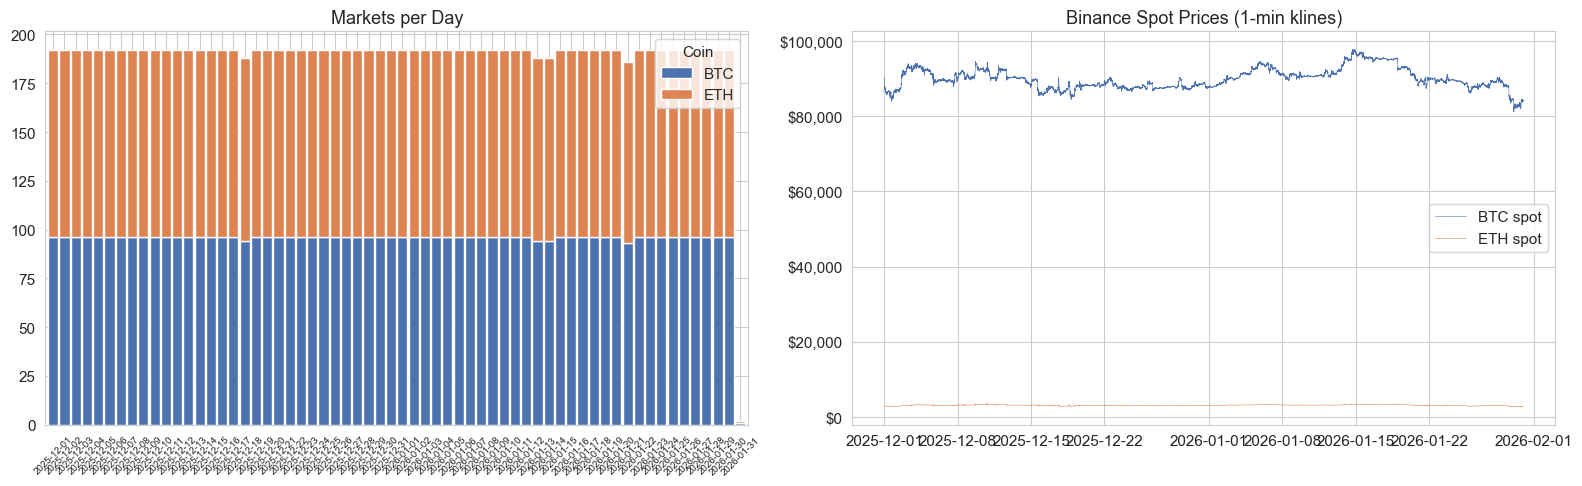

In [4]:
total_trades = pd.read_sql_query(
    'SELECT COUNT(*) as cnt FROM historical_trades', conn).iloc[0, 0]
print(f'Total trades in DB: {total_trades:,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Markets per day
markets['day'] = markets['window_start'].dt.date
daily = markets.groupby(['day', 'coin']).size().unstack(fill_value=0)
daily.plot.bar(ax=axes[0], stacked=True, width=0.9)
axes[0].set_title('Markets per Day')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].legend(title='Coin')

# Kline price time series
for coin in ['BTC', 'ETH']:
    spot = klines[(klines['symbol'] == coin) & (klines['source'] == 'binance-spot')]
    axes[1].plot(spot['datetime'], spot['close'], lw=0.4, label=f'{coin} spot')
axes[1].set_title('Binance Spot Prices (1-min klines)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


## 2. Market Window Construction

For each market, join Binance klines (spot + futures) at window start and end to determine:
- Actual crypto return over the 15-min window
- Actual outcome (up/down)
- Futures–spot basis at both boundaries


In [5]:
cache_path = OUTPUT_DIR / 'market_windows.parquet'

if cache_path.exists():
    mw = pd.read_parquet(cache_path)
    print(f'Loaded cached market windows: {len(mw):,}')
else:
    mw = markets.copy()

    for source in ['binance-spot', 'binance-futures']:
        src_k = klines[klines['source'] == source]

        for boundary, ts_col in [('start', 'window_start_ts'), ('end', 'window_end_ts')]:
            col = f'{source}_{boundary}_close'
            vals = np.full(len(mw), np.nan)

            for coin in ['BTC', 'ETH']:
                coin_mask = mw['coin'].values == coin
                coin_idx = np.where(coin_mask)[0]
                ck = src_k[src_k['symbol'] == coin].sort_values('timestamp')
                if len(ck) == 0:
                    continue

                k_ts = ck['timestamp'].values.astype(np.int64)
                k_close = ck['close'].values
                targets = mw[ts_col].values[coin_mask].astype(np.int64)

                # Vectorized nearest-neighbor kline lookup
                pos = np.searchsorted(k_ts, targets)
                pos = np.clip(pos, 0, len(k_ts) - 1)
                pos_prev = np.clip(pos - 1, 0, len(k_ts) - 1)

                d_right = np.abs(k_ts[pos] - targets)
                d_left = np.abs(k_ts[pos_prev] - targets)

                best = np.where(d_left < d_right, pos_prev, pos)
                best_d = np.minimum(d_left, d_right)

                matched = np.where(best_d <= 120, k_close[best], np.nan)
                vals[coin_idx] = matched

                # Diagnostic on first iteration
                if boundary == 'start' and source == 'binance-spot':
                    n_matched = np.sum(~np.isnan(matched))
                    print(f'  {coin} {source} {boundary}: {n_matched}/{len(matched)} matched '
                          f'(kline range [{k_ts[0]}, {k_ts[-1]}], '
                          f'target range [{targets.min()}, {targets.max()}])')

            mw[col] = vals

    # Returns and outcomes (only set outcome when kline data exists)
    for src in ['binance-spot', 'binance-futures']:
        sc, ec = f'{src}_start_close', f'{src}_end_close'
        has_data = mw[sc].notna() & mw[ec].notna()
        mw[f'{src}_return_pct'] = np.where(has_data, (mw[ec] - mw[sc]) / mw[sc] * 100, np.nan)
        mw[f'{src}_outcome'] = np.where(has_data, np.where(mw[ec] >= mw[sc], 'up', 'down'), None)

    # Basis
    mw['basis_start_pct'] = (
        (mw['binance-futures_start_close'] - mw['binance-spot_start_close'])
        / mw['binance-spot_start_close'] * 100)
    mw['basis_end_pct'] = (
        (mw['binance-futures_end_close'] - mw['binance-spot_end_close'])
        / mw['binance-spot_end_close'] * 100)

    mw.to_parquet(cache_path, index=False)
    print(f'Built and cached market windows: {len(mw):,}')

valid = mw['binance-spot_return_pct'].notna()
print(f'Markets with kline data: {valid.sum():,} / {len(mw):,} ({valid.mean()*100:.1f}%)')
print(f'\nSpot return stats:\n{mw.loc[valid, "binance-spot_return_pct"].describe()}')

  BTC binance-spot start: 5848/5848 matched (kline range [1764547200, 1769817600], target range [1764547200, 1769817600])
  ETH binance-spot start: 5848/5848 matched (kline range [1764547200, 1769817600], target range [1764547200, 1769817600])
Built and cached market windows: 11,696
Markets with kline data: 11,694 / 11,696 (100.0%)

Spot return stats:
count    11694.000000
mean        -0.001058
std          0.271839
min         -3.343653
25%         -0.101456
50%          0.000017
75%          0.103513
max          3.164965
Name: binance-spot_return_pct, dtype: float64


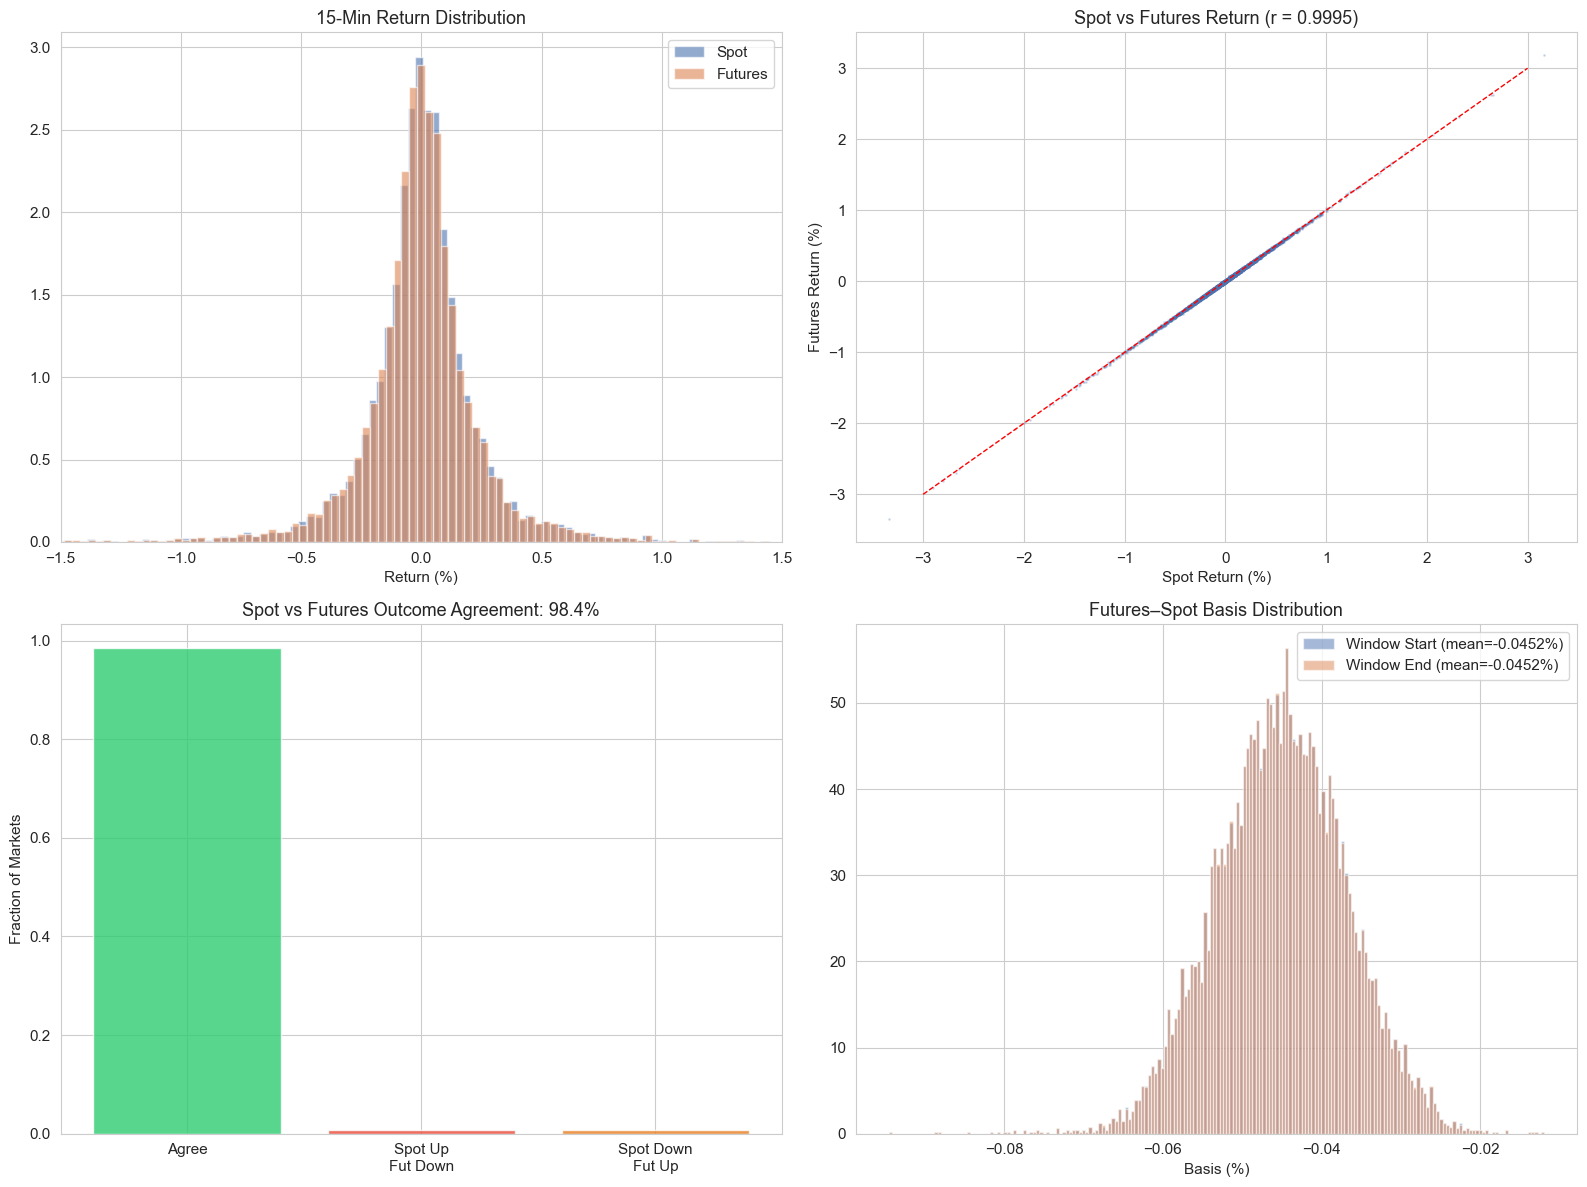


BTC: 5,847 markets, mean return -0.0009%, up rate 49.7%

ETH: 5,847 markets, mean return -0.0012%, up rate 50.6%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
valid = mw['binance-spot_return_pct'].notna()
vm = mw[valid]

# 1. Return distribution
axes[0,0].hist(vm['binance-spot_return_pct'], bins=200, alpha=0.6, label='Spot', density=True)
axes[0,0].hist(vm['binance-futures_return_pct'], bins=200, alpha=0.6, label='Futures', density=True)
axes[0,0].set_title('15-Min Return Distribution')
axes[0,0].set_xlabel('Return (%)')
axes[0,0].legend()
axes[0,0].set_xlim(-1.5, 1.5)

# 2. Spot vs Futures scatter
axes[0,1].scatter(vm['binance-spot_return_pct'], vm['binance-futures_return_pct'],
                  s=1, alpha=0.2, rasterized=True)
axes[0,1].plot([-3, 3], [-3, 3], 'r--', lw=1)
r = vm[['binance-spot_return_pct', 'binance-futures_return_pct']].corr().iloc[0,1]
axes[0,1].set_title(f'Spot vs Futures Return (r = {r:.4f})')
axes[0,1].set_xlabel('Spot Return (%)')
axes[0,1].set_ylabel('Futures Return (%)')

# 3. Outcome agreement
agree = (vm['binance-spot_outcome'] == vm['binance-futures_outcome']).mean()
disagree_up = ((vm['binance-spot_outcome'] == 'up') & (vm['binance-futures_outcome'] == 'down')).mean()
disagree_dn = ((vm['binance-spot_outcome'] == 'down') & (vm['binance-futures_outcome'] == 'up')).mean()
axes[1,0].bar(['Agree', 'Spot Up\nFut Down', 'Spot Down\nFut Up'],
              [agree, disagree_up, disagree_dn],
              color=['#2ecc71', '#e74c3c', '#e67e22'], alpha=0.8)
axes[1,0].set_title(f'Spot vs Futures Outcome Agreement: {agree*100:.1f}%')
axes[1,0].set_ylabel('Fraction of Markets')

# 4. Basis distribution
for col, label in [('basis_start_pct', 'Window Start'), ('basis_end_pct', 'Window End')]:
    d = vm[col].dropna()
    axes[1,1].hist(d, bins=200, alpha=0.5, label=f'{label} (mean={d.mean():.4f}%)', density=True)
axes[1,1].set_title('Futures–Spot Basis Distribution')
axes[1,1].set_xlabel('Basis (%)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Summary by coin
for coin in ['BTC', 'ETH']:
    cm = vm[vm['coin'] == coin]
    print(f'\n{coin}: {len(cm):,} markets, '
          f'mean return {cm["binance-spot_return_pct"].mean():.4f}%, '
          f'up rate {(cm["binance-spot_outcome"]=="up").mean()*100:.1f}%')


## 3. Bet Price Trajectories

For each market, load Polymarket trades for `token_a` (Up outcome):
- Resample to 10-second bins using last-observation-carried-forward
- Normalize time axis to [0, 1] (0 = window start, 1 = settlement)
- Extract final bet price & bet direction

Batch-processed 200 markets at a time to avoid full-table scans on ~99M trades.


In [7]:
cache_traj = OUTPUT_DIR / 'bet_trajectories.parquet'
N_BINS = 90  # 10s bins for 15 min

if cache_traj.exists():
    traj_df = pd.read_parquet(cache_traj)
    # Rebuild price matrix from stored trajectories
    pm = np.array(traj_df['trajectory'].tolist())
    print(f'Loaded cached trajectories: {len(traj_df):,} markets')
else:
    batch_size = 200
    sorted_m = mw[mw['binance-spot_outcome'].notna()].sort_values('window_start_ts').reset_index(drop=True)
    print(f'Markets with valid outcome for trajectory analysis: {len(sorted_m):,}')

    if len(sorted_m) == 0:
        raise RuntimeError('No markets with valid kline data. Re-run Section 2 after deleting output/market_windows.parquet')

    traj_records = []
    price_matrix = []
    debug_empty_batches = 0

    for batch_start in tqdm(range(0, len(sorted_m), batch_size), desc='Loading bet trades'):
        batch = sorted_m.iloc[batch_start:batch_start + batch_size]
        token_ids = batch['token_a'].tolist()
        min_ts = int(batch['window_start_ts'].min()) - 60
        max_ts = int(batch['window_end_ts'].max()) + 60

        placeholders = ','.join(['?'] * len(token_ids))
        trades = pd.read_sql_query(
            f'SELECT token_id, timestamp, CAST(price AS REAL) as price '
            f'FROM historical_trades '
            f'WHERE token_id IN ({placeholders}) AND timestamp BETWEEN ? AND ? '
            f'ORDER BY token_id, timestamp',
            conn, params=token_ids + [min_ts, max_ts])

        if len(trades) == 0:
            debug_empty_batches += 1
            if debug_empty_batches == 1:
                print(f'  DEBUG: empty batch! token_ids[0]={token_ids[0][:30]}..., '
                      f'ts range=[{min_ts}, {max_ts}]')
            continue

        batch_added = 0
        for _, market in batch.iterrows():
            t = trades[
                (trades['token_id'] == market['token_a']) &
                (trades['timestamp'] >= market['window_start_ts']) &
                (trades['timestamp'] <= market['window_end_ts'])]

            if len(t) < 2:
                continue

            ws, we = market['window_start_ts'], market['window_end_ts']
            duration = we - ws
            if duration <= 0:
                continue

            t_norm = (t['timestamp'].values - ws) / duration
            prices = t['price'].values

            # Bin into N_BINS slots, last price per bin
            bin_idx = np.clip(np.floor(t_norm * N_BINS).astype(int), 0, N_BINS - 1)
            binned = np.full(N_BINS, np.nan)
            for bi, p in zip(bin_idx, prices):
                binned[bi] = p

            # Forward-fill then back-fill to remove NaN
            binned = pd.Series(binned).ffill().bfill().values
            if np.isnan(binned).any():
                continue

            final_price = binned[-1]

            traj_records.append({
                'market_id': market['market_id'],
                'coin': market['coin'],
                'final_bet_price': final_price,
                'bet_direction': 'up' if final_price > 0.5 else 'down',
                'actual_outcome': market['binance-spot_outcome'],
                'spot_return_pct': market['binance-spot_return_pct'],
                'futures_return_pct': market['binance-futures_return_pct'],
                'n_trades': len(t),
                'trajectory': binned.tolist(),
            })
            price_matrix.append(binned)
            batch_added += 1

    if debug_empty_batches > 0:
        print(f'  WARNING: {debug_empty_batches} batches returned 0 trades from DB')

    traj_df = pd.DataFrame(traj_records)
    if len(traj_df) == 0:
        raise RuntimeError(f'No valid trajectories produced from {len(sorted_m)} markets. '
                          f'Check that trade token_ids match market token_a values.')

    traj_df['bet_correct'] = traj_df['bet_direction'] == traj_df['actual_outcome']
    pm = np.array(price_matrix)

    traj_df.to_parquet(cache_traj, index=False)
    print(f'Processed {len(traj_df):,} markets with valid trajectories')
    print(f'Price matrix shape: {pm.shape}')

print(f'\nBet direction accuracy: {traj_df["bet_correct"].mean()*100:.1f}%')
print(f'Final bet price stats:\n{traj_df["final_bet_price"].describe()}')

Markets with valid outcome for trajectory analysis: 11,694


Loading bet trades:   0%|          | 0/59 [00:00<?, ?it/s]

Processed 11,592 markets with valid trajectories
Price matrix shape: (11592, 90)

Bet direction accuracy: 87.1%
Final bet price stats:
count    11592.000000
mean         0.515004
std          0.479359
min          0.001000
25%          0.010000
50%          0.741936
75%          0.990000
max          0.999000
Name: final_bet_price, dtype: float64


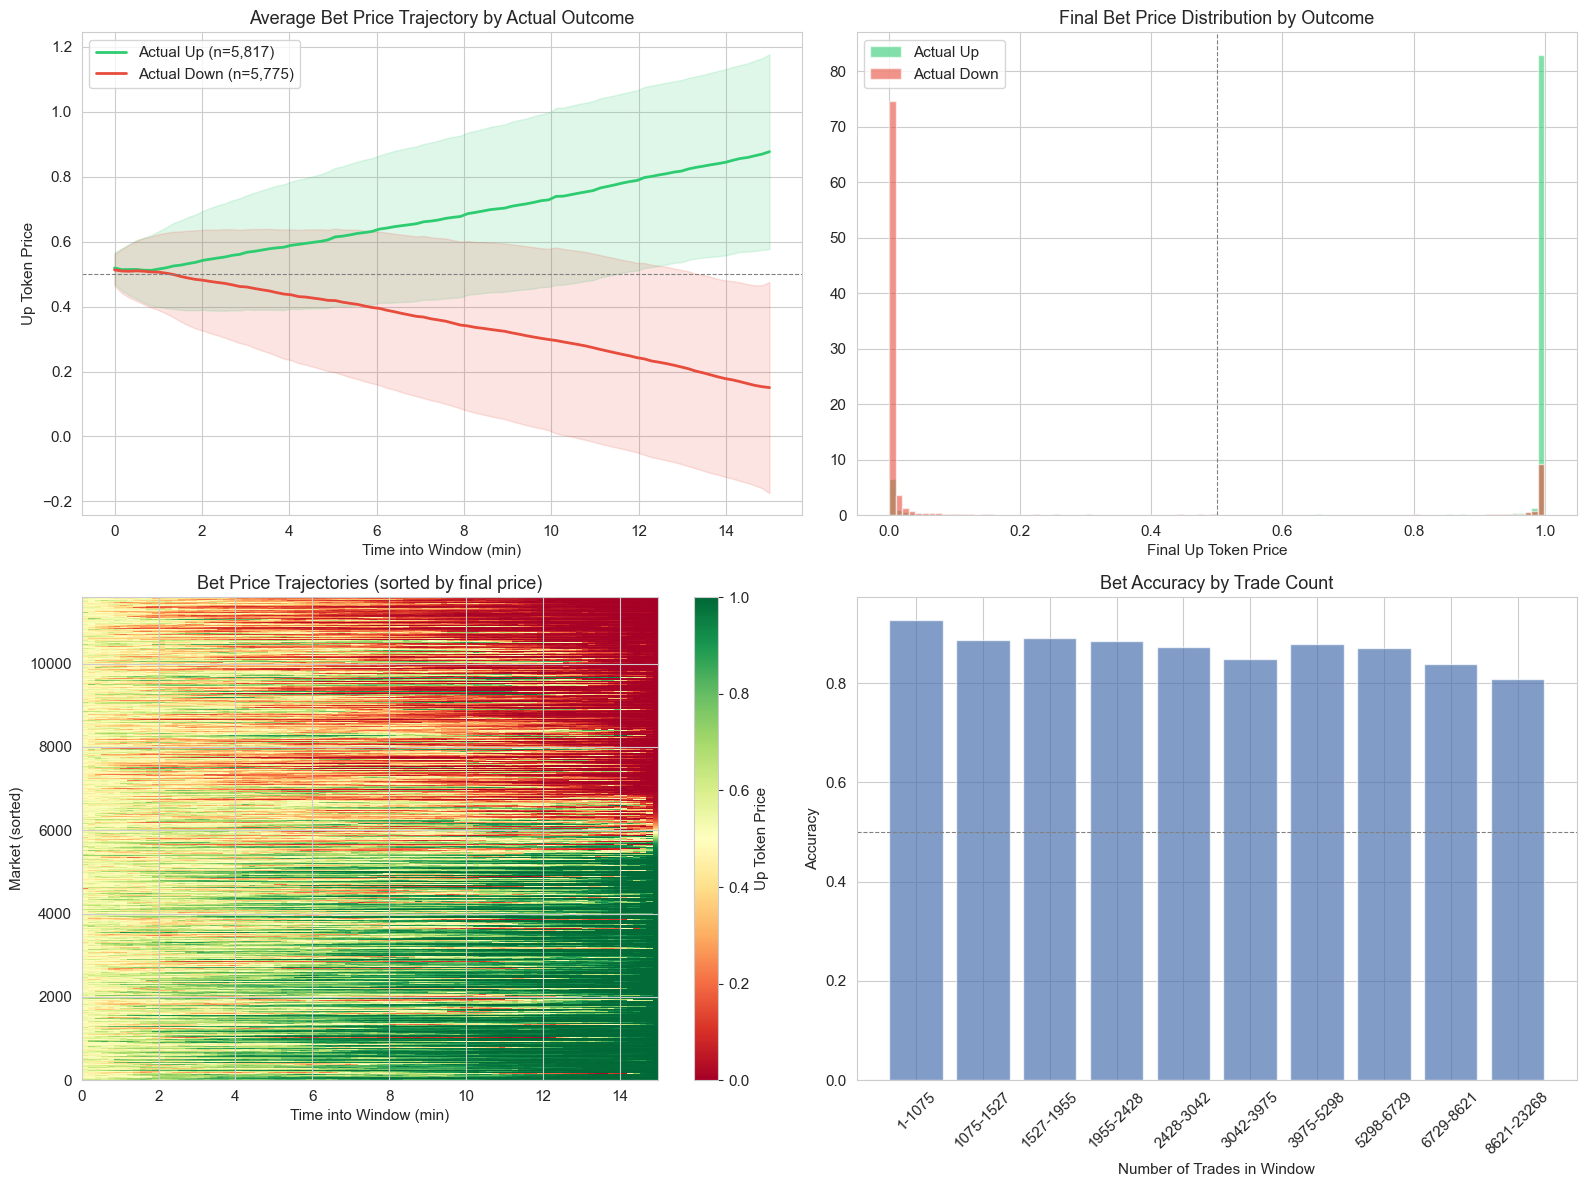

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
t_axis = np.linspace(0, 15, N_BINS)  # minutes

# 1. Average trajectory by actual outcome
for outcome, color, label in [('up', '#2ecc71', 'Actual Up'), ('down', '#e74c3c', 'Actual Down')]:
    mask = traj_df['actual_outcome'].values == outcome
    subset = pm[mask[:len(pm)]]
    mean = np.nanmean(subset, axis=0)
    std = np.nanstd(subset, axis=0)
    axes[0,0].plot(t_axis, mean, color=color, label=f'{label} (n={mask.sum():,})', lw=2)
    axes[0,0].fill_between(t_axis, mean - std, mean + std, color=color, alpha=0.15)
axes[0,0].axhline(0.5, ls='--', color='gray', lw=0.8)
axes[0,0].set_title('Average Bet Price Trajectory by Actual Outcome')
axes[0,0].set_xlabel('Time into Window (min)')
axes[0,0].set_ylabel('Up Token Price')
axes[0,0].legend()

# 2. Final bet price distribution
axes[0,1].hist(traj_df[traj_df['actual_outcome'] == 'up']['final_bet_price'],
               bins=100, alpha=0.6, label='Actual Up', color='#2ecc71', density=True)
axes[0,1].hist(traj_df[traj_df['actual_outcome'] == 'down']['final_bet_price'],
               bins=100, alpha=0.6, label='Actual Down', color='#e74c3c', density=True)
axes[0,1].axvline(0.5, ls='--', color='gray', lw=0.8)
axes[0,1].set_title('Final Bet Price Distribution by Outcome')
axes[0,1].set_xlabel('Final Up Token Price')
axes[0,1].legend()

# 3. Heatmap: price trajectories sorted by final price
sort_idx = np.argsort(pm[:, -1])
axes[1,0].imshow(pm[sort_idx], aspect='auto', cmap='RdYlGn',
                 extent=[0, 15, 0, len(pm)], vmin=0, vmax=1, interpolation='none')
axes[1,0].set_title('Bet Price Trajectories (sorted by final price)')
axes[1,0].set_xlabel('Time into Window (min)')
axes[1,0].set_ylabel('Market (sorted)')
cb = plt.colorbar(axes[1,0].images[0], ax=axes[1,0])
cb.set_label('Up Token Price')

# 4. Trade count vs accuracy
bins_n = pd.qcut(traj_df['n_trades'], 10, duplicates='drop')
acc_by_trades = traj_df.groupby(bins_n, observed=True)['bet_correct'].mean()
axes[1,1].bar(range(len(acc_by_trades)), acc_by_trades.values, alpha=0.7)
axes[1,1].set_xticks(range(len(acc_by_trades)))
axes[1,1].set_xticklabels([f'{int(i.left)}-{int(i.right)}' for i in acc_by_trades.index], rotation=45)
axes[1,1].set_title('Bet Accuracy by Trade Count')
axes[1,1].set_xlabel('Number of Trades in Window')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].axhline(0.5, ls='--', color='gray', lw=0.8)

plt.tight_layout()
plt.show()


## 4. Correlation Analysis

- **Cross-sectional accuracy**: % of markets where final bet direction agrees with outcome
- **Calibration curve**: bin by bet price, plot actual win rate (reliability diagram + Brier score)
- **Scatter**: spot return vs bet price deviation from 0.5
- **Accuracy by**: coin, time of day, move magnitude


Overall bet accuracy: 87.1%
  BTC: 86.7% (n=5,797)
  ETH: 87.5% (n=5,795)


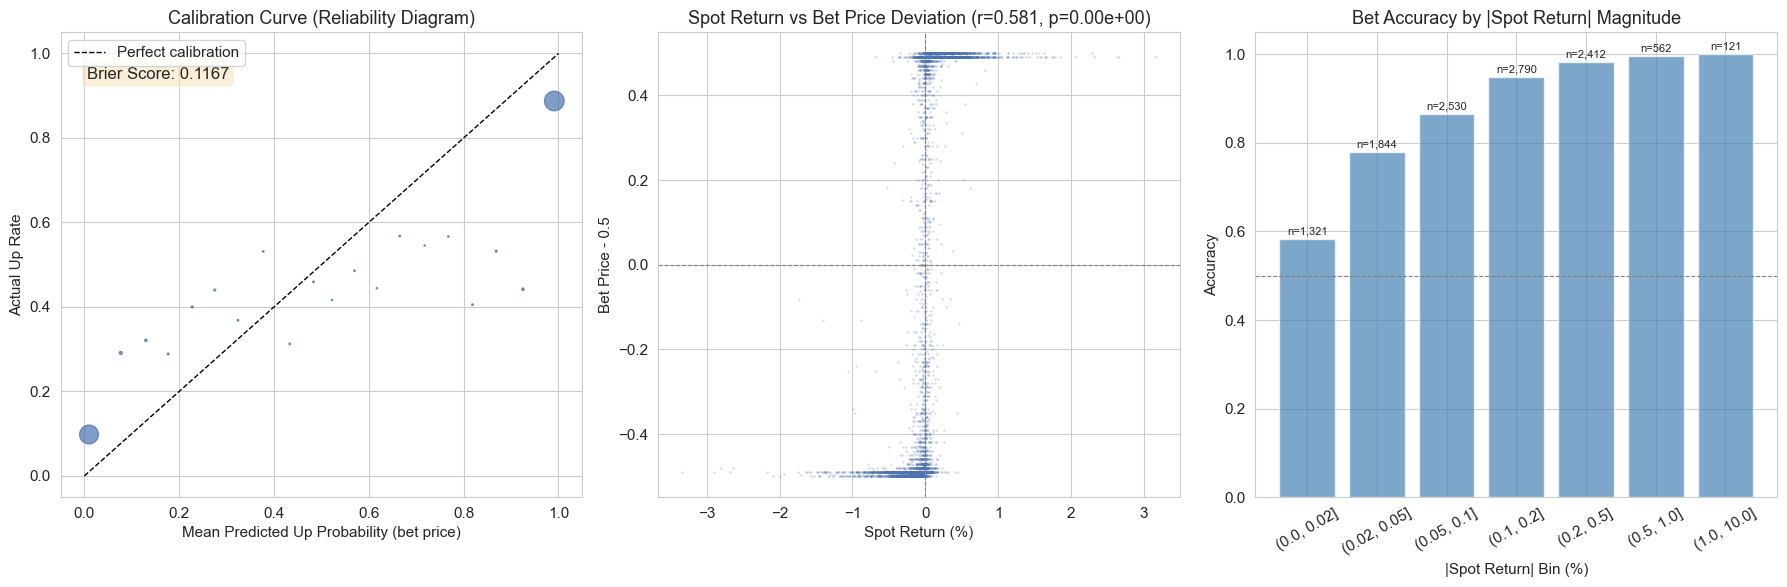

In [9]:
# --- Cross-sectional accuracy ---
overall_acc = traj_df['bet_correct'].mean()
print(f'Overall bet accuracy: {overall_acc*100:.1f}%')
for coin in ['BTC', 'ETH']:
    cm = traj_df[traj_df['coin'] == coin]
    print(f'  {coin}: {cm["bet_correct"].mean()*100:.1f}% (n={len(cm):,})')

# --- Calibration curve (reliability diagram) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Bin final bet prices into deciles
n_cal_bins = 20
traj_df['price_bin'] = pd.cut(traj_df['final_bet_price'], bins=n_cal_bins)
cal = traj_df.groupby('price_bin', observed=True).agg(
    mean_predicted=('final_bet_price', 'mean'),
    actual_up_rate=('actual_outcome', lambda x: (x == 'up').mean()),
    count=('market_id', 'size')).dropna()

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
axes[0].scatter(cal['mean_predicted'], cal['actual_up_rate'],
                s=cal['count'] / cal['count'].max() * 200, alpha=0.7)
axes[0].set_title('Calibration Curve (Reliability Diagram)')
axes[0].set_xlabel('Mean Predicted Up Probability (bet price)')
axes[0].set_ylabel('Actual Up Rate')
axes[0].legend()

# Brier score
brier = np.mean((traj_df['final_bet_price'] - (traj_df['actual_outcome'] == 'up').astype(float))**2)
axes[0].text(0.05, 0.9, f'Brier Score: {brier:.4f}', transform=axes[0].transAxes,
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- Scatter: spot return vs bet price deviation ---
axes[1].scatter(traj_df['spot_return_pct'],
                traj_df['final_bet_price'] - 0.5,
                s=1, alpha=0.15, rasterized=True)
axes[1].axhline(0, ls='--', color='gray', lw=0.8)
axes[1].axvline(0, ls='--', color='gray', lw=0.8)
r, p = stats.pearsonr(
    traj_df['spot_return_pct'].dropna(),
    (traj_df['final_bet_price'] - 0.5).loc[traj_df['spot_return_pct'].notna()])
axes[1].set_title(f'Spot Return vs Bet Price Deviation (r={r:.3f}, p={p:.2e})')
axes[1].set_xlabel('Spot Return (%)')
axes[1].set_ylabel('Bet Price - 0.5')

# --- Accuracy by move magnitude ---
traj_df['abs_return'] = traj_df['spot_return_pct'].abs()
mag_bins = [0, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 10.0]
traj_df['mag_bin'] = pd.cut(traj_df['abs_return'], bins=mag_bins)
mag_acc = traj_df.groupby('mag_bin', observed=True).agg(
    accuracy=('bet_correct', 'mean'),
    count=('market_id', 'size'))

axes[2].bar(range(len(mag_acc)), mag_acc['accuracy'], alpha=0.7, color='steelblue')
for i, (_, row) in enumerate(mag_acc.iterrows()):
    axes[2].text(i, row['accuracy'] + 0.01, f'n={int(row["count"]):,}',
                 ha='center', fontsize=8)
axes[2].set_xticks(range(len(mag_acc)))
axes[2].set_xticklabels([str(i) for i in mag_acc.index], rotation=30)
axes[2].axhline(0.5, ls='--', color='gray', lw=0.8)
axes[2].set_title('Bet Accuracy by |Spot Return| Magnitude')
axes[2].set_xlabel('|Spot Return| Bin (%)')
axes[2].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()


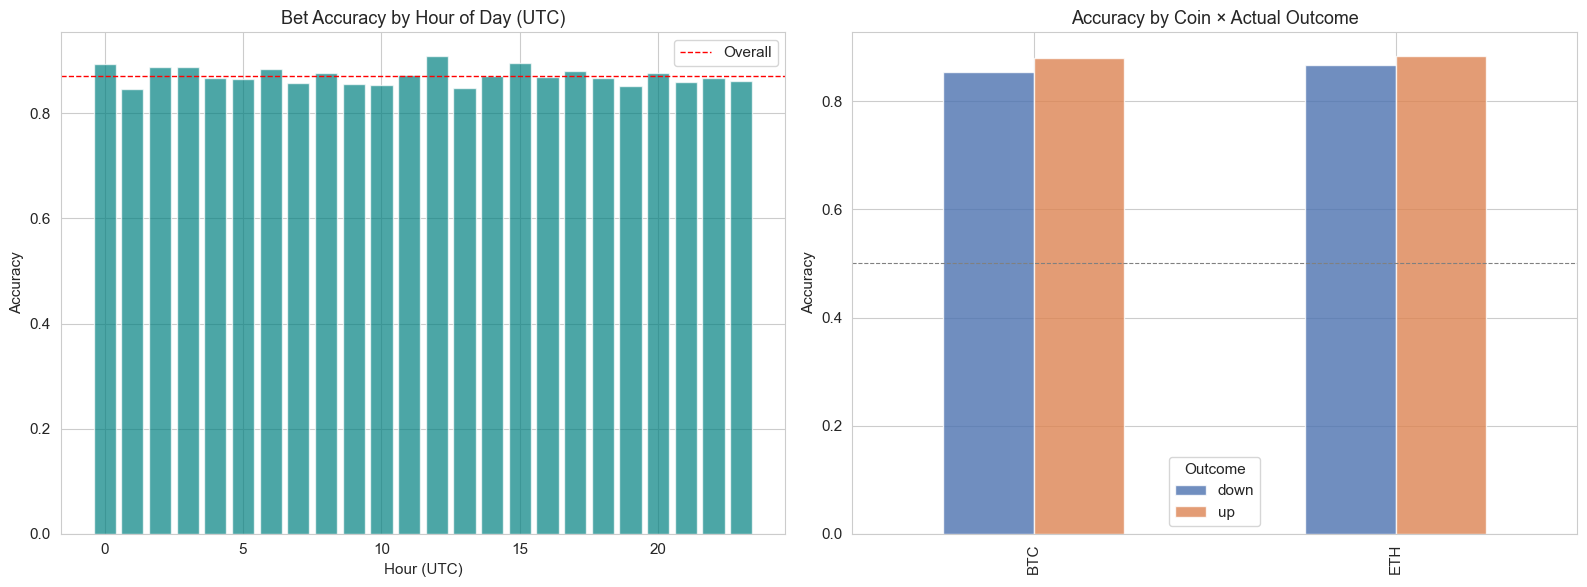

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Merge window_start time for time-of-day analysis
traj_with_time = traj_df.merge(
    mw[['market_id', 'window_start']], on='market_id', how='left')
traj_with_time['hour'] = traj_with_time['window_start'].dt.hour

# Accuracy by hour
hourly = traj_with_time.groupby('hour').agg(
    accuracy=('bet_correct', 'mean'),
    count=('market_id', 'size'))
axes[0].bar(hourly.index, hourly['accuracy'], alpha=0.7, color='teal')
axes[0].axhline(traj_df['bet_correct'].mean(), ls='--', color='red', lw=1, label='Overall')
axes[0].set_title('Bet Accuracy by Hour of Day (UTC)')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Accuracy by coin + direction
pivot = traj_df.groupby(['coin', 'actual_outcome'])['bet_correct'].mean().unstack()
pivot.plot.bar(ax=axes[1], alpha=0.8)
axes[1].axhline(0.5, ls='--', color='gray', lw=0.8)
axes[1].set_title('Accuracy by Coin × Actual Outcome')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('')
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.show()


## 5. Market Efficiency / Lead-Lag

- **Information ratio by time remaining**: how does correlation between bet price and outcome
  improve as the window matures?
- **Event-time response**: for 1-min crypto shocks (>0.1%), measure bet price adjustment speed
- **Cross-correlation**: between crypto returns and bet price changes at lags -5 to +5 min
- **Granger causality**: VAR(1-5) — do crypto prices cause bet prices, or vice versa?


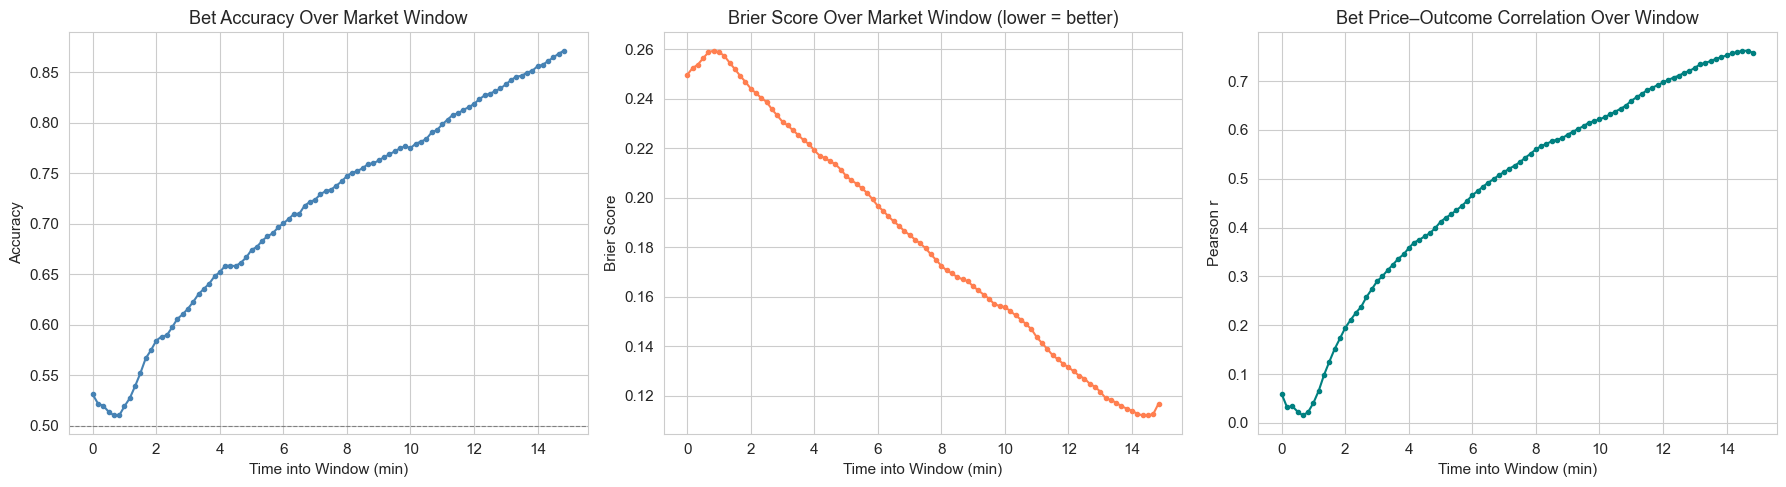

Accuracy at t=0: 0.531
Accuracy at t=7.5min: 0.734
Accuracy at t=14min: 0.857
Accuracy at t=15min: 0.871


In [11]:
# For each 10s bin, compute how well the bet price predicts the final outcome
# This shows information accumulation over the market window

actual_up = (traj_df['actual_outcome'].values == 'up').astype(float)
n_markets = len(pm)

info_by_bin = []
for i in range(N_BINS):
    prices_at_i = pm[:, i]
    valid_mask = ~np.isnan(prices_at_i)
    if valid_mask.sum() < 100:
        continue
    p = prices_at_i[valid_mask]
    a = actual_up[valid_mask]

    # Brier score at this time point (lower = more informative)
    brier_i = np.mean((p - a)**2)
    # Accuracy at this time point
    pred_up = (p > 0.5).astype(float)
    acc_i = np.mean(pred_up == a)
    # Correlation
    r_i = np.corrcoef(p, a)[0, 1] if np.std(p) > 0 else 0

    info_by_bin.append({
        'bin': i,
        'time_min': i * 15 / N_BINS,
        'time_remaining_min': 15 - i * 15 / N_BINS,
        'brier': brier_i,
        'accuracy': acc_i,
        'correlation': r_i,
    })

info_df = pd.DataFrame(info_by_bin)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(info_df['time_min'], info_df['accuracy'], 'o-', markersize=3, color='steelblue')
axes[0].axhline(0.5, ls='--', color='gray', lw=0.8)
axes[0].set_title('Bet Accuracy Over Market Window')
axes[0].set_xlabel('Time into Window (min)')
axes[0].set_ylabel('Accuracy')

axes[1].plot(info_df['time_min'], info_df['brier'], 'o-', markersize=3, color='coral')
axes[1].set_title('Brier Score Over Market Window (lower = better)')
axes[1].set_xlabel('Time into Window (min)')
axes[1].set_ylabel('Brier Score')

axes[2].plot(info_df['time_min'], info_df['correlation'], 'o-', markersize=3, color='teal')
axes[2].set_title('Bet Price–Outcome Correlation Over Window')
axes[2].set_xlabel('Time into Window (min)')
axes[2].set_ylabel('Pearson r')

plt.tight_layout()
plt.show()

print(f'Accuracy at t=0: {info_df.iloc[0]["accuracy"]:.3f}')
print(f'Accuracy at t=7.5min: {info_df.iloc[N_BINS//2]["accuracy"]:.3f}')
print(f'Accuracy at t=14min: {info_df.iloc[-5]["accuracy"]:.3f}')
print(f'Accuracy at t=15min: {info_df.iloc[-1]["accuracy"]:.3f}')


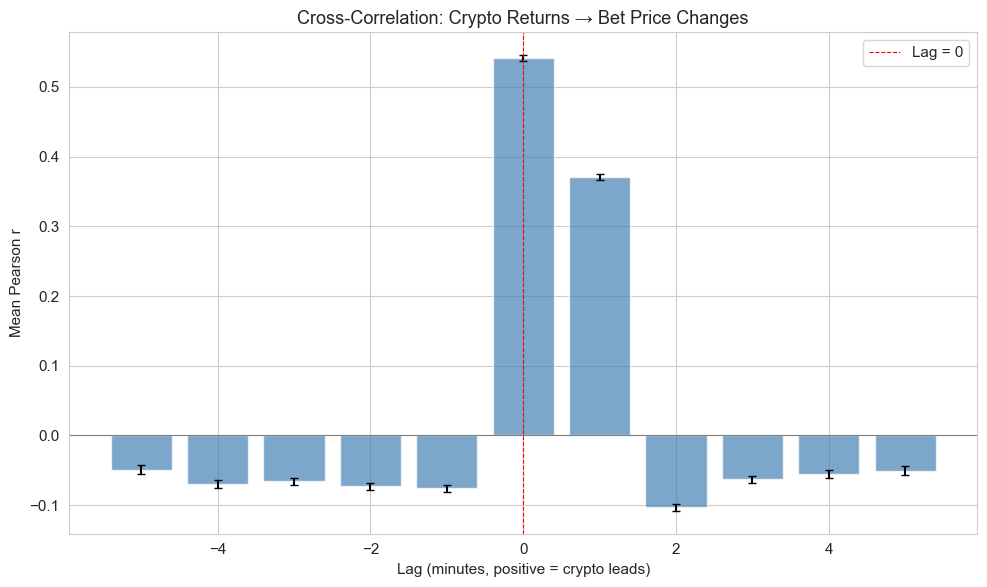

Cross-correlation summary:
 lag_min  mean_corr       se     n
      -5  -0.049080 0.003229 11583
      -4  -0.069142 0.003023 11584
      -3  -0.065859 0.002803 11588
      -2  -0.072836 0.002650 11590
      -1  -0.076047 0.002558 11590
       0   0.541724 0.001994 11590
       1   0.370955 0.002357 11588
       2  -0.103307 0.002515 11588
       3  -0.062843 0.002725 11588
       4  -0.055856 0.002911 11585
       5  -0.050541 0.003192 11585


In [12]:
# For each market, build aligned 1-min bet price changes and crypto price changes,
# then compute cross-correlation at various lags.

# We use 1-min bins (15 bins per market) to match kline resolution.
BINS_1MIN = 15

# Rebuild 1-min bet price series
bet_1min = np.full((len(pm), BINS_1MIN), np.nan)
for i in range(BINS_1MIN):
    # Average the 6 sub-bins (10s) that make up each 1-min bin
    start_sub = i * (N_BINS // BINS_1MIN)
    end_sub = start_sub + (N_BINS // BINS_1MIN)
    bet_1min[:, i] = np.nanmean(pm[:, start_sub:end_sub], axis=1)

# Build 1-min crypto return series for each market
# Merge market metadata for kline lookup
traj_meta = traj_df[['market_id', 'coin']].copy()
traj_meta = traj_meta.merge(mw[['market_id', 'window_start_ts', 'window_end_ts']], on='market_id')

crypto_1min = np.full((len(traj_meta), BINS_1MIN), np.nan)

for coin in ['BTC', 'ETH']:
    coin_mask = traj_meta['coin'].values == coin
    coin_idx = np.where(coin_mask)[0]

    spot_k = klines[(klines['symbol'] == coin) & (klines['source'] == 'binance-spot')].sort_values('timestamp')
    if len(spot_k) == 0:
        continue

    k_ts = spot_k['timestamp'].values.astype(np.int64)
    k_close = spot_k['close'].values

    for j in coin_idx:
        ws = int(traj_meta.iloc[j]['window_start_ts'])
        for b in range(BINS_1MIN):
            target = ws + b * 60
            pos = np.searchsorted(k_ts, target)
            pos = np.clip(pos, 0, len(k_ts) - 1)
            pos_prev = np.clip(pos - 1, 0, len(k_ts) - 1)
            best = pos_prev if abs(k_ts[pos_prev] - target) < abs(k_ts[pos] - target) else pos
            if abs(k_ts[best] - target) <= 120:
                crypto_1min[j, b] = k_close[best]

# Compute changes (returns)
bet_changes = np.diff(bet_1min, axis=1)  # (N, 14)
crypto_returns = np.diff(crypto_1min, axis=1) / crypto_1min[:, :-1] * 100  # (N, 14)

# Cross-correlation at lags -5 to +5 (1-min bins)
max_lag = 5
lags = range(-max_lag, max_lag + 1)
xcorr = []

for lag in lags:
    corrs = []
    for i in range(len(bet_changes)):
        b = bet_changes[i]
        c = crypto_returns[i]
        if np.isnan(b).any() or np.isnan(c).any():
            continue

        if lag >= 0:
            b_slice = b[lag:]
            c_slice = c[:len(b_slice)]
        else:
            c_slice = c[-lag:]
            b_slice = b[:len(c_slice)]

        if len(b_slice) < 3 or np.std(b_slice) == 0 or np.std(c_slice) == 0:
            continue
        corrs.append(np.corrcoef(b_slice, c_slice)[0, 1])

    xcorr.append({
        'lag_min': lag,
        'mean_corr': np.mean(corrs) if corrs else 0,
        'se': np.std(corrs) / np.sqrt(len(corrs)) if len(corrs) > 1 else 0,
        'n': len(corrs)
    })

xcorr_df = pd.DataFrame(xcorr)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(xcorr_df['lag_min'], xcorr_df['mean_corr'],
       yerr=xcorr_df['se'] * 1.96, capsize=3, alpha=0.7, color='steelblue')
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='red', ls='--', lw=0.8, label='Lag = 0')
ax.set_title('Cross-Correlation: Crypto Returns → Bet Price Changes')
ax.set_xlabel('Lag (minutes, positive = crypto leads)')
ax.set_ylabel('Mean Pearson r')
ax.legend()
plt.tight_layout()
plt.show()

print('Cross-correlation summary:')
print(xcorr_df.to_string(index=False))


In [13]:
from statsmodels.tsa.stattools import grangercausalitytests

# Run Granger causality on pooled 1-min series (stack all markets)
# Crypto → Bet direction
valid_rows = ~(np.isnan(bet_changes).any(axis=1) | np.isnan(crypto_returns).any(axis=1))
n_valid = valid_rows.sum()
print(f'Valid markets for Granger test: {n_valid:,}')

if n_valid >= 100:
    # Stack into long series (separated by NaN to avoid cross-market leakage — use chunks)
    # Simple approach: test on a random subset of 500 markets with sufficient length
    sample_idx = np.where(valid_rows)[0]
    np.random.seed(42)
    sample_idx = np.random.choice(sample_idx, min(500, len(sample_idx)), replace=False)

    # Pool the series
    pooled_bet = np.concatenate([bet_changes[i] for i in sample_idx])
    pooled_crypto = np.concatenate([crypto_returns[i] for i in sample_idx])

    data = pd.DataFrame({'bet_change': pooled_bet, 'crypto_return': pooled_crypto}).dropna()

    print('\n--- Granger: Crypto → Bet ---')
    try:
        gc_crypto_to_bet = grangercausalitytests(
            data[['bet_change', 'crypto_return']], maxlag=3, verbose=False)
        for lag, result in gc_crypto_to_bet.items():
            f_stat = result[0]['ssr_ftest'][0]
            p_val = result[0]['ssr_ftest'][1]
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
            print(f'  Lag {lag}: F={f_stat:.2f}, p={p_val:.4f} {sig}')
    except Exception as e:
        print(f'  Failed: {e}')

    print('\n--- Granger: Bet → Crypto ---')
    try:
        gc_bet_to_crypto = grangercausalitytests(
            data[['crypto_return', 'bet_change']], maxlag=3, verbose=False)
        for lag, result in gc_bet_to_crypto.items():
            f_stat = result[0]['ssr_ftest'][0]
            p_val = result[0]['ssr_ftest'][1]
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
            print(f'  Lag {lag}: F={f_stat:.2f}, p={p_val:.4f} {sig}')
    except Exception as e:
        print(f'  Failed: {e}')
else:
    print('Not enough valid markets for Granger test')


Valid markets for Granger test: 11,592

--- Granger: Crypto → Bet ---
  Lag 1: F=541.32, p=0.0000 ***
  Lag 2: F=268.43, p=0.0000 ***
  Lag 3: F=178.08, p=0.0000 ***

--- Granger: Bet → Crypto ---
  Lag 1: F=7.40, p=0.0065 **
  Lag 2: F=7.04, p=0.0009 ***
  Lag 3: F=4.93, p=0.0020 **


## 6. Futures Frontrunning Detection

- **Basis trajectory around settlement**: `futures - spot` in [-5 min, +5 min] around window end
- **Futures–spot lead/lag near settlement**: cross-correlation near settlement window
- **Settlement-time reversal**: compare spot return in last 2 min vs first 2 min after settlement
- **Conditional basis**: split by outcome and move size


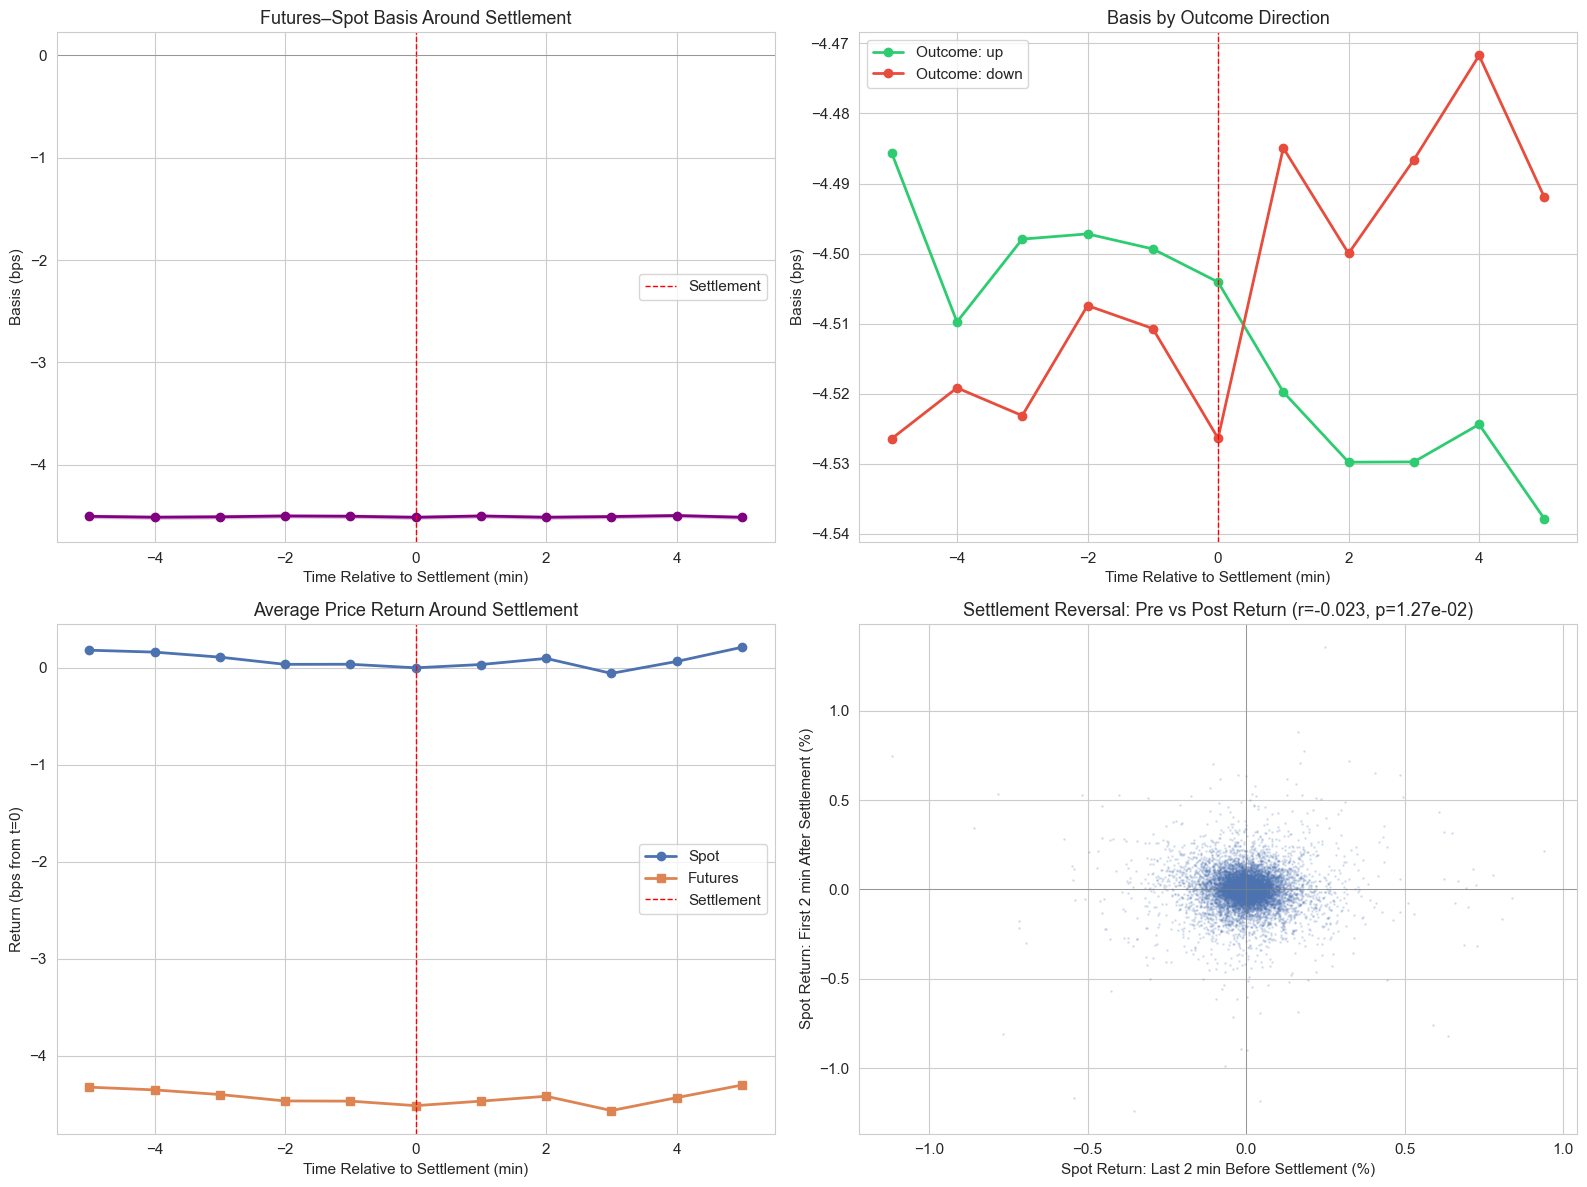


Settlement reversal test:
  Pearson r = -0.0230 (p = 1.27e-02)
  Negative correlation → evidence of reversal/manipulation
  Mean pre-settle return: -0.0003%
  Mean post-settle return: 0.0010%


In [14]:
# Build kline series around settlement for each market
# For each market, we want klines in [window_end - 5min, window_end + 5min]
WINDOW_HALF = 5  # minutes around settlement
KLINE_RES = 60   # 1-min kline resolution

valid_mw = mw[mw['binance-spot_end_close'].notna()].copy()

# Pre-index klines for fast lookup
spot_klines = {}
fut_klines = {}
for coin in ['BTC', 'ETH']:
    sk = klines[(klines['symbol'] == coin) & (klines['source'] == 'binance-spot')].sort_values('timestamp')
    fk = klines[(klines['symbol'] == coin) & (klines['source'] == 'binance-futures')].sort_values('timestamp')
    spot_klines[coin] = (sk['timestamp'].values, sk['close'].values)
    fut_klines[coin] = (fk['timestamp'].values, fk['close'].values)

def lookup_price(ts_arr, close_arr, target_ts, tol=90):
    pos = np.searchsorted(ts_arr, target_ts)
    pos = np.clip(pos, 0, len(ts_arr) - 1)
    pp = np.clip(pos - 1, 0, len(ts_arr) - 1)
    best = np.where(np.abs(ts_arr[pp] - target_ts) < np.abs(ts_arr[pos] - target_ts), pp, pos)
    prices = np.where(np.abs(ts_arr[best] - target_ts) <= tol, close_arr[best], np.nan)
    return prices

# Time offsets around settlement: -5 to +5 min at 1-min steps
offsets = np.arange(-WINDOW_HALF, WINDOW_HALF + 1) * 60
n_offsets = len(offsets)

# Allocate arrays: (n_markets, n_offsets)
spot_prices = np.full((len(valid_mw), n_offsets), np.nan)
fut_prices = np.full((len(valid_mw), n_offsets), np.nan)

for coin in ['BTC', 'ETH']:
    coin_mask = valid_mw['coin'].values == coin
    coin_idx = np.where(coin_mask)[0]
    if len(coin_idx) == 0:
        continue

    settlement_ts = valid_mw['window_end_ts'].values[coin_mask].astype(np.int64)
    s_ts, s_close = spot_klines[coin]
    f_ts, f_close = fut_klines[coin]

    for j, offset in enumerate(offsets):
        targets = settlement_ts + offset
        spot_prices[coin_idx, j] = lookup_price(s_ts, s_close, targets)
        fut_prices[coin_idx, j] = lookup_price(f_ts, f_close, targets)

# Basis = futures - spot (in basis points)
spot_at_settle = spot_prices[:, WINDOW_HALF][:, np.newaxis]  # price at t=0
basis_bps = (fut_prices - spot_prices) / spot_at_settle * 10000

# Normalize prices to returns from t=0
spot_returns = (spot_prices - spot_at_settle) / spot_at_settle * 10000
fut_returns = (fut_prices - spot_at_settle) / spot_at_settle * 10000

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
offset_min = offsets / 60

# 1. Average basis trajectory around settlement
mean_basis = np.nanmean(basis_bps, axis=0)
se_basis = np.nanstd(basis_bps, axis=0) / np.sqrt(np.sum(~np.isnan(basis_bps), axis=0))
axes[0,0].plot(offset_min, mean_basis, 'o-', color='purple', lw=2)
axes[0,0].fill_between(offset_min, mean_basis - 1.96*se_basis, mean_basis + 1.96*se_basis,
                        color='purple', alpha=0.2)
axes[0,0].axvline(0, color='red', ls='--', lw=1, label='Settlement')
axes[0,0].axhline(0, color='gray', lw=0.5)
axes[0,0].set_title('Futures–Spot Basis Around Settlement')
axes[0,0].set_xlabel('Time Relative to Settlement (min)')
axes[0,0].set_ylabel('Basis (bps)')
axes[0,0].legend()

# 2. Conditional basis by outcome
for outcome, color in [('up', '#2ecc71'), ('down', '#e74c3c')]:
    mask = valid_mw['binance-spot_outcome'].values == outcome
    m = np.nanmean(basis_bps[mask], axis=0)
    axes[0,1].plot(offset_min, m, 'o-', color=color, label=f'Outcome: {outcome}', lw=2)
axes[0,1].axvline(0, color='red', ls='--', lw=1)
axes[0,1].set_title('Basis by Outcome Direction')
axes[0,1].set_xlabel('Time Relative to Settlement (min)')
axes[0,1].set_ylabel('Basis (bps)')
axes[0,1].legend()

# 3. Average spot + futures returns around settlement
axes[1,0].plot(offset_min, np.nanmean(spot_returns, axis=0), 'o-', label='Spot', lw=2)
axes[1,0].plot(offset_min, np.nanmean(fut_returns, axis=0), 's-', label='Futures', lw=2)
axes[1,0].axvline(0, color='red', ls='--', lw=1, label='Settlement')
axes[1,0].set_title('Average Price Return Around Settlement')
axes[1,0].set_xlabel('Time Relative to Settlement (min)')
axes[1,0].set_ylabel('Return (bps from t=0)')
axes[1,0].legend()

# 4. Settlement reversal test
# Return in last 2 min before settlement vs first 2 min after
pre_settle_ret = spot_prices[:, WINDOW_HALF] - spot_prices[:, WINDOW_HALF - 2]
post_settle_ret = spot_prices[:, WINDOW_HALF + 2] - spot_prices[:, WINDOW_HALF]
pre_ret_pct = pre_settle_ret / spot_prices[:, WINDOW_HALF - 2] * 100
post_ret_pct = post_settle_ret / spot_prices[:, WINDOW_HALF] * 100

valid_rev = ~(np.isnan(pre_ret_pct) | np.isnan(post_ret_pct))
r_rev, p_rev = stats.pearsonr(pre_ret_pct[valid_rev], post_ret_pct[valid_rev])

axes[1,1].scatter(pre_ret_pct[valid_rev], post_ret_pct[valid_rev],
                  s=1, alpha=0.15, rasterized=True)
axes[1,1].axhline(0, color='gray', lw=0.5)
axes[1,1].axvline(0, color='gray', lw=0.5)
axes[1,1].set_title(f'Settlement Reversal: Pre vs Post Return (r={r_rev:.3f}, p={p_rev:.2e})')
axes[1,1].set_xlabel('Spot Return: Last 2 min Before Settlement (%)')
axes[1,1].set_ylabel('Spot Return: First 2 min After Settlement (%)')

plt.tight_layout()
plt.show()

# Reversal statistics
print(f'\nSettlement reversal test:')
print(f'  Pearson r = {r_rev:.4f} (p = {p_rev:.2e})')
print(f'  {"Negative correlation → evidence of reversal/manipulation" if r_rev < -0.01 and p_rev < 0.05 else "No significant reversal detected"}')
print(f'  Mean pre-settle return: {np.nanmean(pre_ret_pct):.4f}%')
print(f'  Mean post-settle return: {np.nanmean(post_ret_pct):.4f}%')


## 7. Volume Analysis

- **Binance volume profile**: normalized volume around settlement times
- **Polymarket bet volume "smile"**: trade volume by relative time within window
- **Abnormal volume vs returns**: does futures volume around settlement predict spot moves?


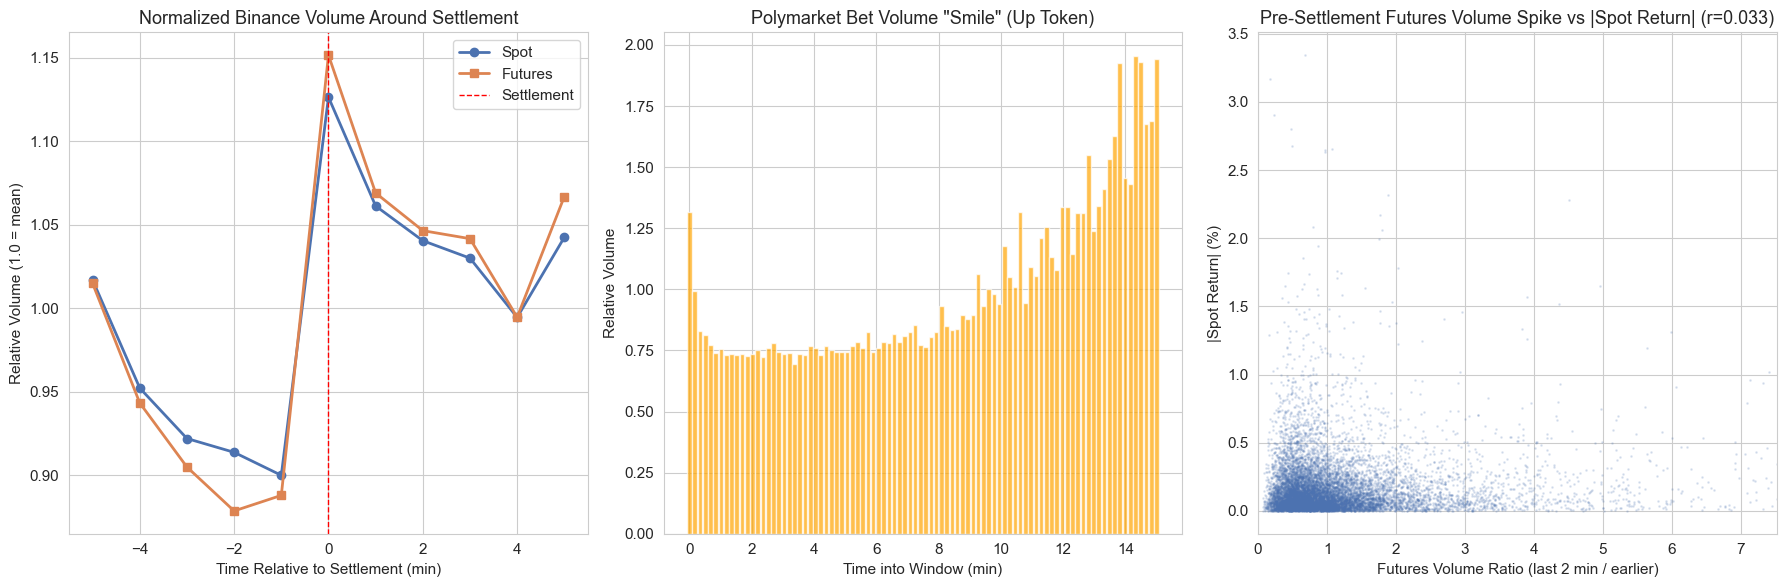

In [15]:
# --- Binance volume around settlement ---
# Build volume arrays similar to price arrays
spot_vol = np.full((len(valid_mw), n_offsets), np.nan)
fut_vol = np.full((len(valid_mw), n_offsets), np.nan)

# Pre-index volume data
for coin in ['BTC', 'ETH']:
    coin_mask = valid_mw['coin'].values == coin
    coin_idx = np.where(coin_mask)[0]
    if len(coin_idx) == 0:
        continue

    settlement_ts = valid_mw['window_end_ts'].values[coin_mask].astype(np.int64)

    for src, vol_arr, src_name in [('binance-spot', spot_vol, 'spot'),
                                    ('binance-futures', fut_vol, 'futures')]:
        k = klines[(klines['symbol'] == coin) & (klines['source'] == src)].sort_values('timestamp')
        if len(k) == 0:
            continue
        k_ts = k['timestamp'].values
        k_vol = k['volume'].values

        for j, offset in enumerate(offsets):
            targets = settlement_ts + offset
            pos = np.searchsorted(k_ts, targets)
            pos = np.clip(pos, 0, len(k_ts) - 1)
            pp = np.clip(pos - 1, 0, len(k_ts) - 1)
            best = np.where(np.abs(k_ts[pp] - targets) < np.abs(k_ts[pos] - targets), pp, pos)
            valid = np.abs(k_ts[best] - targets) <= 90
            vol_arr[coin_idx[valid], j] = k_vol[best[valid]]

# Normalize volume: divide each market's volume by its mean
spot_vol_norm = spot_vol / np.nanmean(spot_vol, axis=1, keepdims=True)
fut_vol_norm = fut_vol / np.nanmean(fut_vol, axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Binance volume around settlement
axes[0].plot(offset_min, np.nanmean(spot_vol_norm, axis=0), 'o-', label='Spot', lw=2)
axes[0].plot(offset_min, np.nanmean(fut_vol_norm, axis=0), 's-', label='Futures', lw=2)
axes[0].axvline(0, color='red', ls='--', lw=1, label='Settlement')
axes[0].set_title('Normalized Binance Volume Around Settlement')
axes[0].set_xlabel('Time Relative to Settlement (min)')
axes[0].set_ylabel('Relative Volume (1.0 = mean)')
axes[0].legend()

# 2. Polymarket bet volume "smile" — volume by position in window
# Load total trade count per bin for sampled markets
sample_mids = traj_df['market_id'].sample(min(1000, len(traj_df)), random_state=42).tolist()
sample_markets = mw[mw['market_id'].isin(sample_mids)].copy()
sample_tokens = sample_markets['token_a'].tolist()

bet_volume_bins = np.zeros(N_BINS)
bet_volume_count = np.zeros(N_BINS)

for batch_start in range(0, len(sample_markets), 200):
    batch = sample_markets.iloc[batch_start:batch_start + 200]
    tokens = batch['token_a'].tolist()
    min_ts = int(batch['window_start_ts'].min()) - 60
    max_ts = int(batch['window_end_ts'].max()) + 60

    ph = ','.join(['?'] * len(tokens))
    trades = pd.read_sql_query(
        f'SELECT token_id, timestamp, CAST(size AS REAL) as size '
        f'FROM historical_trades WHERE token_id IN ({ph}) AND timestamp BETWEEN ? AND ? ',
        conn, params=tokens + [min_ts, max_ts])

    for _, market in batch.iterrows():
        t = trades[
            (trades['token_id'] == market['token_a']) &
            (trades['timestamp'] >= market['window_start_ts']) &
            (trades['timestamp'] <= market['window_end_ts'])]
        if len(t) == 0:
            continue
        ws, we = market['window_start_ts'], market['window_end_ts']
        dur = we - ws
        if dur <= 0:
            continue
        t_norm = (t['timestamp'].values - ws) / dur
        bins = np.clip(np.floor(t_norm * N_BINS).astype(int), 0, N_BINS - 1)
        for bi, sz in zip(bins, t['size'].values):
            bet_volume_bins[bi] += sz
            bet_volume_count[bi] += 1

avg_bet_vol = bet_volume_bins / np.maximum(bet_volume_count, 1)
avg_bet_vol_norm = avg_bet_vol / avg_bet_vol.mean()

t_axis = np.linspace(0, 15, N_BINS)
axes[1].bar(t_axis, avg_bet_vol_norm, width=15/N_BINS*0.9, alpha=0.7, color='orange')
axes[1].set_title('Polymarket Bet Volume "Smile" (Up Token)')
axes[1].set_xlabel('Time into Window (min)')
axes[1].set_ylabel('Relative Volume')

# 3. Futures volume spike vs subsequent spot return
# Abnormal futures volume in last 2 min before settlement vs spot return
pre_settle_fut_vol = np.nanmean(fut_vol[:, WINDOW_HALF-2:WINDOW_HALF], axis=1)
avg_fut_vol = np.nanmean(fut_vol[:, :WINDOW_HALF-2], axis=1)
vol_ratio = pre_settle_fut_vol / np.maximum(avg_fut_vol, 1e-10)

spot_ret = valid_mw['binance-spot_return_pct'].values
valid_v = ~(np.isnan(vol_ratio) | np.isnan(spot_ret) | np.isinf(vol_ratio))
if valid_v.sum() > 100:
    axes[2].scatter(vol_ratio[valid_v], np.abs(spot_ret[valid_v]),
                    s=1, alpha=0.15, rasterized=True)
    r_v, p_v = stats.pearsonr(vol_ratio[valid_v], np.abs(spot_ret[valid_v]))
    axes[2].set_title(f'Pre-Settlement Futures Volume Spike vs |Spot Return| (r={r_v:.3f})')
    axes[2].set_xlabel('Futures Volume Ratio (last 2 min / earlier)')
    axes[2].set_ylabel('|Spot Return| (%)')
    axes[2].set_xlim(0, np.percentile(vol_ratio[valid_v], 99))

plt.tight_layout()
plt.show()


## 8. High-Resolution Frontrunning (1s aggTrades)

Fetch Binance spot + futures aggTrades for 500 random markets in [-2 min, +2 min]
around settlement at 1-second resolution.

- Endpoints: `/api/v3/aggTrades` (spot), `/fapi/v1/aggTrades` (futures) — public, no auth
- Rate limit: 2400 req/min — comfortably fits 2000 requests


In [16]:
cache_granular = OUTPUT_DIR / 'granular_trades.parquet'

if cache_granular.exists():
    granular = pd.read_parquet(cache_granular)
    print(f'Loaded cached granular trades: {len(granular):,}')
else:
    # Sample 500 random markets
    np.random.seed(42)
    sample = valid_mw.sample(min(500, len(valid_mw))).copy()
    print(f'Fetching aggTrades for {len(sample)} markets...')

    all_agg = []
    errors = 0

    for i, (_, market) in enumerate(tqdm(sample.iterrows(), total=len(sample), desc='Fetching aggTrades')):
        coin = market['coin']
        symbol = f'{coin}USDT'
        settle_ts = int(market['window_end_ts'])
        start_ms = (settle_ts - 120) * 1000  # -2 min
        end_ms = (settle_ts + 120) * 1000    # +2 min

        for src, base_url in [('spot', 'https://api.binance.com/api/v3/aggTrades'),
                               ('futures', 'https://fapi.binance.com/fapi/v1/aggTrades')]:
            try:
                resp = requests.get(base_url, params={
                    'symbol': symbol, 'startTime': start_ms,
                    'endTime': end_ms, 'limit': 1000}, timeout=10)
                if resp.status_code == 429:
                    time.sleep(30)
                    resp = requests.get(base_url, params={
                        'symbol': symbol, 'startTime': start_ms,
                        'endTime': end_ms, 'limit': 1000}, timeout=10)
                if resp.status_code == 200:
                    data = resp.json()
                    for t in data:
                        all_agg.append({
                            'market_id': market['market_id'],
                            'coin': coin,
                            'source': src,
                            'timestamp_ms': t['T'],
                            'price': float(t['p']),
                            'qty': float(t['q']),
                            'is_buyer_maker': t['m'],
                            'settle_ts': settle_ts,
                        })
                else:
                    errors += 1
            except Exception:
                errors += 1

        # Rate limiting: ~4 requests per market, stay under 2400/min
        if (i + 1) % 50 == 0:
            time.sleep(2)

    granular = pd.DataFrame(all_agg)
    if len(granular) > 0:
        granular['offset_sec'] = (granular['timestamp_ms'] / 1000 - granular['settle_ts'])
        granular.to_parquet(cache_granular, index=False)
    print(f'Fetched {len(granular):,} aggTrades ({errors} errors)')


Fetching aggTrades for 500 markets...


Fetching aggTrades:   0%|          | 0/500 [00:00<?, ?it/s]

Fetched 946,039 aggTrades (0 errors)


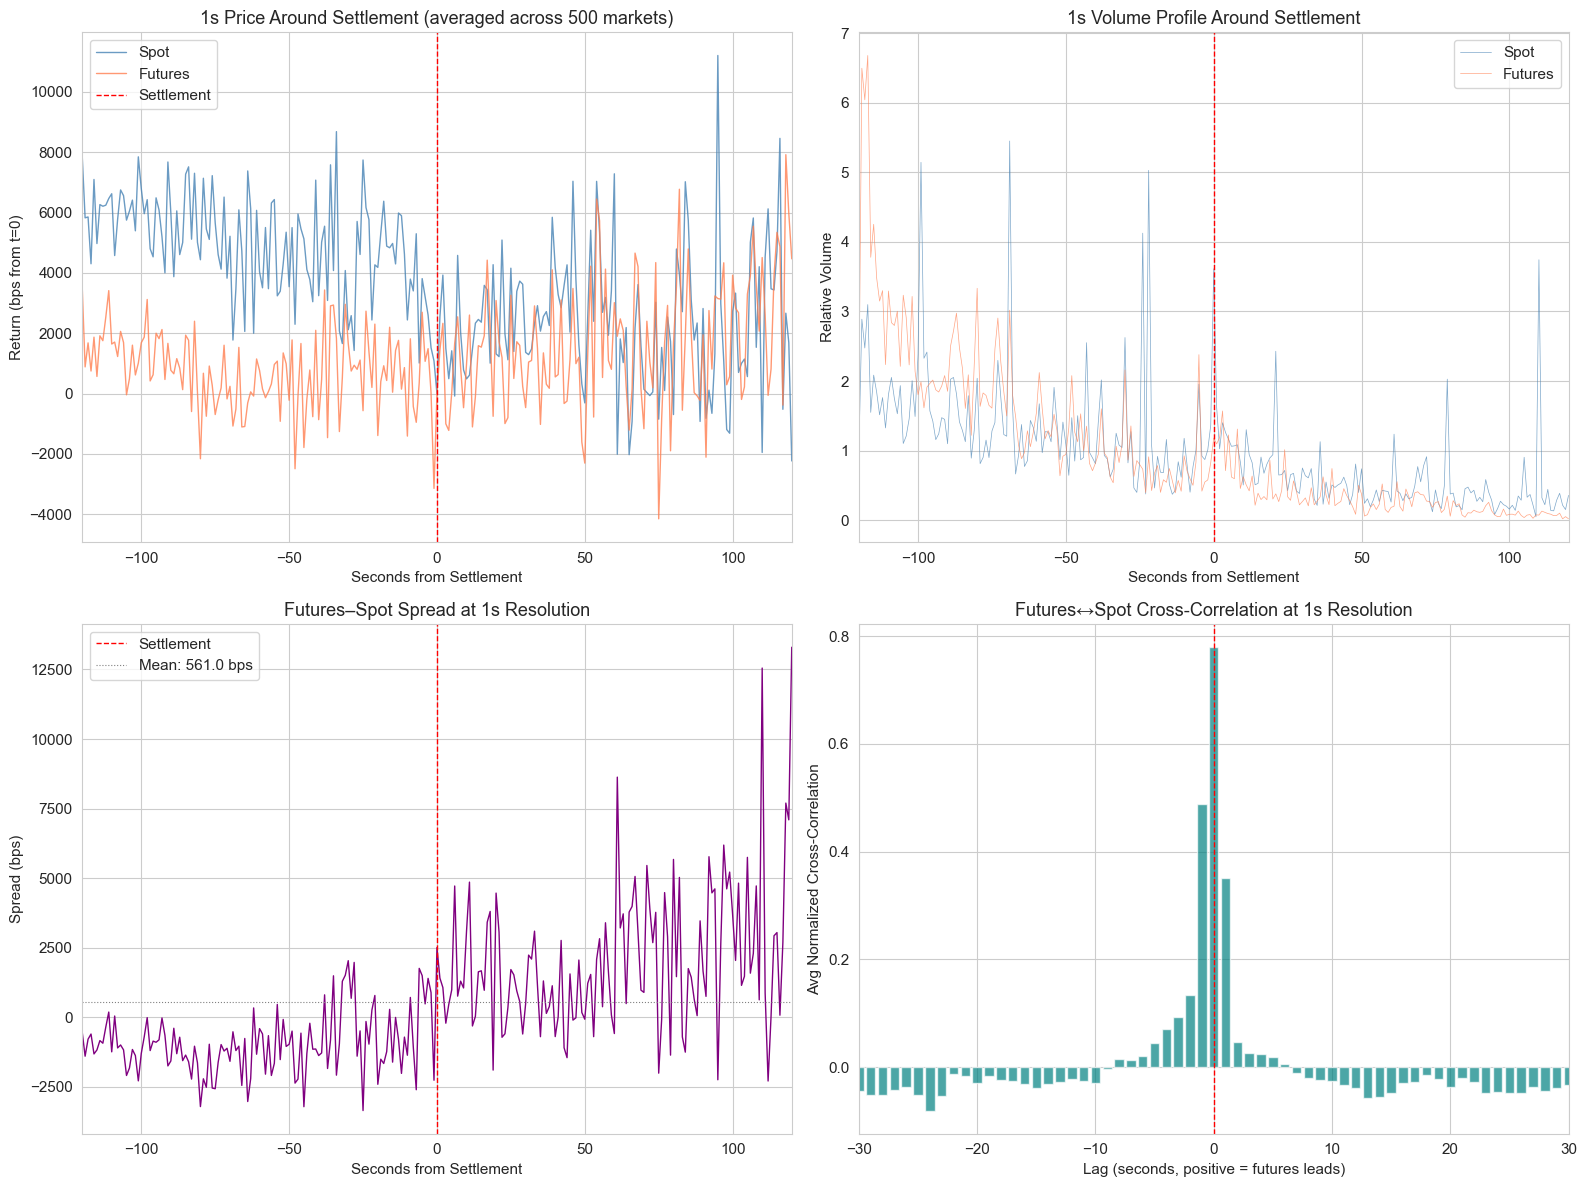

In [17]:
if len(granular) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Sub-second price comparison: spot vs futures around settlement
    for src, color, label in [('spot', 'steelblue', 'Spot'), ('futures', 'coral', 'Futures')]:
        subset = granular[granular['source'] == src]
        # Bin by 1-second intervals
        subset = subset.copy()
        subset['sec_bin'] = subset['offset_sec'].round(0)
        binned = subset.groupby('sec_bin').agg(
            mean_price=('price', 'mean'),
            total_qty=('qty', 'sum'))
        # Normalize to t=0
        p0 = binned.loc[binned.index == 0, 'mean_price']
        if len(p0) > 0:
            norm = (binned['mean_price'] / p0.values[0] - 1) * 10000
            axes[0,0].plot(binned.index, norm, lw=1, label=label, color=color, alpha=0.8)

    axes[0,0].axvline(0, color='red', ls='--', lw=1, label='Settlement')
    axes[0,0].set_title('1s Price Around Settlement (averaged across 500 markets)')
    axes[0,0].set_xlabel('Seconds from Settlement')
    axes[0,0].set_ylabel('Return (bps from t=0)')
    axes[0,0].legend()
    axes[0,0].set_xlim(-120, 120)

    # 2. Volume profile at 1s resolution
    for src, color, label in [('spot', 'steelblue', 'Spot'), ('futures', 'coral', 'Futures')]:
        subset = granular[granular['source'] == src].copy()
        subset['sec_bin'] = subset['offset_sec'].round(0)
        vol = subset.groupby('sec_bin')['qty'].sum()
        vol_norm = vol / vol.mean()
        axes[0,1].plot(vol.index, vol_norm, lw=0.5, label=label, color=color, alpha=0.7)

    axes[0,1].axvline(0, color='red', ls='--', lw=1)
    axes[0,1].set_title('1s Volume Profile Around Settlement')
    axes[0,1].set_xlabel('Seconds from Settlement')
    axes[0,1].set_ylabel('Relative Volume')
    axes[0,1].legend()
    axes[0,1].set_xlim(-120, 120)

    # 3. Futures-spot spread at 1s resolution
    spot_1s = granular[granular['source'] == 'spot'].copy()
    fut_1s = granular[granular['source'] == 'futures'].copy()
    spot_1s['sec_bin'] = spot_1s['offset_sec'].round(0)
    fut_1s['sec_bin'] = fut_1s['offset_sec'].round(0)

    spot_avg = spot_1s.groupby('sec_bin')['price'].mean()
    fut_avg = fut_1s.groupby('sec_bin')['price'].mean()
    common = spot_avg.index.intersection(fut_avg.index)
    spread_bps = (fut_avg[common] - spot_avg[common]) / spot_avg[common] * 10000

    axes[1,0].plot(common, spread_bps, lw=1, color='purple')
    axes[1,0].axvline(0, color='red', ls='--', lw=1, label='Settlement')
    axes[1,0].axhline(spread_bps.mean(), color='gray', ls=':', lw=0.8, label=f'Mean: {spread_bps.mean():.1f} bps')
    axes[1,0].set_title('Futures–Spot Spread at 1s Resolution')
    axes[1,0].set_xlabel('Seconds from Settlement')
    axes[1,0].set_ylabel('Spread (bps)')
    axes[1,0].legend()
    axes[1,0].set_xlim(-120, 120)

    # 4. Cross-correlation at 1s lags
    # For each market, compute 1s-binned spot and futures returns, then cross-correlate
    sample_mids = granular['market_id'].unique()[:100]
    lags_1s = np.arange(-30, 31)
    xcorr_1s = np.zeros(len(lags_1s))
    xcorr_count = 0

    for mid in sample_mids:
        mg = granular[granular['market_id'] == mid]
        sp = mg[mg['source'] == 'spot'].copy()
        fu = mg[mg['source'] == 'futures'].copy()
        if len(sp) < 10 or len(fu) < 10:
            continue

        sp['sec_bin'] = sp['offset_sec'].round(0)
        fu['sec_bin'] = fu['offset_sec'].round(0)
        sp_p = sp.groupby('sec_bin')['price'].mean()
        fu_p = fu.groupby('sec_bin')['price'].mean()

        common_idx = sp_p.index.intersection(fu_p.index)
        if len(common_idx) < 30:
            continue

        sp_ret = sp_p[common_idx].diff().dropna()
        fu_ret = fu_p[common_idx].diff().dropna()
        ci = sp_ret.index.intersection(fu_ret.index)
        if len(ci) < 20:
            continue

        s = sp_ret[ci].values
        f = fu_ret[ci].values
        s = (s - s.mean()) / (s.std() + 1e-10)
        f = (f - f.mean()) / (f.std() + 1e-10)

        for k, lag in enumerate(lags_1s):
            if lag >= 0:
                f_s = f[lag:]
                s_s = s[:len(f_s)]
            else:
                s_s = s[-lag:]
                f_s = f[:len(s_s)]
            if len(f_s) >= 10:
                xcorr_1s[k] += np.mean(f_s * s_s)
                xcorr_count += 1

    if xcorr_count > 0:
        xcorr_1s /= (xcorr_count / len(lags_1s))

    axes[1,1].bar(lags_1s, xcorr_1s, alpha=0.7, color='teal', width=0.8)
    axes[1,1].axvline(0, color='red', ls='--', lw=1)
    axes[1,1].set_title('Futures↔Spot Cross-Correlation at 1s Resolution')
    axes[1,1].set_xlabel('Lag (seconds, positive = futures leads)')
    axes[1,1].set_ylabel('Avg Normalized Cross-Correlation')
    axes[1,1].set_xlim(-30, 30)

    plt.tight_layout()
    plt.show()
else:
    print('No granular trade data available. Run the fetch cell above first.')


## Summary

In [18]:
# Export per-market summary CSV
summary = traj_df[['market_id', 'coin', 'final_bet_price', 'bet_direction',
                   'actual_outcome', 'bet_correct', 'spot_return_pct',
                   'futures_return_pct', 'n_trades']].copy()

# Merge window metadata
summary = summary.merge(
    mw[['market_id', 'window_start', 'end_date', 'basis_start_pct', 'basis_end_pct']],
    on='market_id', how='left')

summary.to_csv(OUTPUT_DIR / 'market_summary.csv', index=False)
print(f'Exported market_summary.csv: {len(summary):,} rows')

# Final summary statistics
print(f'''
{"="*60}
ANALYSIS SUMMARY
{"="*60}

Markets analyzed:     {len(traj_df):,}
  BTC:                {(traj_df["coin"]=="BTC").sum():,}
  ETH:                {(traj_df["coin"]=="ETH").sum():,}

Bet accuracy:         {traj_df["bet_correct"].mean()*100:.1f}%
Brier score:          {np.mean((traj_df["final_bet_price"] - (traj_df["actual_outcome"]=="up").astype(float))**2):.4f}

Spot-Futures corr:    {mw[["binance-spot_return_pct","binance-futures_return_pct"]].corr().iloc[0,1]:.4f}
Outcome agreement:    {(mw["binance-spot_outcome"]==mw["binance-futures_outcome"]).mean()*100:.1f}%

Output files:
  output/market_windows.parquet
  output/bet_trajectories.parquet
  output/granular_trades.parquet
  output/market_summary.csv
{"="*60}
''')


Exported market_summary.csv: 11,592 rows

ANALYSIS SUMMARY

Markets analyzed:     11,592
  BTC:                5,797
  ETH:                5,795

Bet accuracy:         87.1%
Brier score:          0.1167

Spot-Futures corr:    0.9995
Outcome agreement:    98.4%

Output files:
  output/market_windows.parquet
  output/bet_trajectories.parquet
  output/granular_trades.parquet
  output/market_summary.csv

